## <h1><center>Assignment 3: Contrastive Learning</center></h1>



<center>
    <img src="https://www.cs.cornell.edu/courses/cs4782/2025sp/images/p3_header.jpeg" style="width:45%;">
</center>



&nbsp;


---


**Goal:** In this project you will be exploring different strategies in contrastive pre-training. You will be using different computer vision models to generate meaningful image features that will later be used to perform image classification on cifar10, a widely used machine learning dataset.

&nbsp;

**WHAT YOU'LL SUBMIT:** Your submission to Gradescope includes:


1.   A `.zip` file uploaded to ***Coding Assignment 3*** [here](https://www.gradescope.com/courses/1245650/assignments/7747035) containing the following files:

<center>

\#|Files
---|---
i. | `submission.py`
ii. |`linear_model_preds.csv`

</center>


2.   A `.pdf` version of `responses.tex` with responses to the questions in this notebook uploaded to ***Coding Assignment 3 Responses*** [here](https://www.gradescope.com/courses/1245650/assignments/7747192).

*More on how you are expected to access, modify and save these files as you follow along the instructions in the notebook.*

&nbsp;

**IMPORTANT:**

This coding assignment requires training 3 separate models for (~30+ minutes each) and thus requires the use of GPUs. In Google Colab, click on the runtime option and change your runtime type to a GPU of your choice. We recommend using the **T4 GPU**. 

Things to keep in mind:
*   Colab Pro users receive 100 compute units per month. This should be more than sufficient for the assignments, but you should still use them wisely.
*   For reference:

    * On a **T4 GPU**, training takes around 30–40 minutes per model, with a compute unit usage rate of ~1.8 units per hour.

    * On an **A100 GPU**, training takes around 20 minutes per model, with a compute unit usage rate of ~7.5 units per hour.

    Again, the choice of GPU is up to you, but please be mindful of your resource usage.
*   To save compute units, disconnect and delete your runtime when you’re done working. Be aware that all local variables and temporary files in the session will be lost, so only disconnect when you’ve finished your work.
*   To check your compute unit usage rate and remaining compute units, go to Runtime > View resources.

&nbsp;

**DO's:**

1.   As before, all functionality you need to modify is within `submission.py`.
2.   Remember to execute all code cells sequentially, not just those you’ve edited, to ensure your code runs properly.
3.   Please cite any external sources you use to complete this assignment in your written responses.
4.   Before starting your work, please review <a href="https://s3.amazonaws.com/ecornell/global/eCornellPlagiarismPolicy.pdf">eCornell's policy regarding plagiarism</a> (the presentation of someone else's work as your own without source credit).

&nbsp;

**DONT's:**


1.   DO NOT leave your GPU instance running after you are done working on this assignment.
2.   DO NOT change the names of any provided functions, classes, or variables within the existing code cells, as this will interfere with grading.
3.   DO NOT delete any provided code/imports.

&nbsp;

***NOTE:***
    
*You can resubmit your work as many times as necessary before the submission deadline. If you experience difficulty or have questions about this exercise, use the Ed discussion board to engage with your peers or seek assistance from the TAs.*

# Part 0: Setting up the Colab environment.

The first few code blocks will set up your Colab environment.  Upload the `a3_release` folder to your Google Drive and run/update the cells below, following the TODO instructions. Just like in the first assignment, you must specify the paths to your implementation so it can be accessed by this notebook (see *TODO 1*).

In [19]:
# Reinstall ipython kernel to enable autoreload on latest runtime (by 02/12/2026)
# You'll be prompted to restart the session.
!pip install ipython==8.12.0

Error in callback <bound method AutoreloadMagics.pre_run_cell of <IPython.extensions.autoreload.AutoreloadMagics object at 0x13e94cad0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 1452e42d0, raw_cell="# Reinstall ipython kernel to enable autoreload on.." transformed_cell="# Reinstall ipython kernel to enable autoreload on.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/Assignment_3.ipynb#W2sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: AutoreloadMagics.pre_run_cell() takes 1 positional argument but 2 were given

In [2]:
!pip install einops
!pip install datasets
!pip install umap-learn


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
  Using cached filelock-3.25.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached numpy-2.4.3-cp314-cp314-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached pyarrow-23.0.1-cp314-cp314-macosx_12_0_arm64.whl.metadata (3.1 kB)
  Using cached pandas-3.0.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached xxhash-3.6.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (13 kB)
  Using cached fsspec-2026.2.0-py3-none-any.whl.metadata (10 kB)
  Using cached pyyaml-6.0.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (2.4 kB)
  Using cached aiohttp-3.13.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (8.1 kB)
  Using cached anyio-4.12.1-py3-none-any.whl.metadata (4.3 kB)
  Using cached certifi-2

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.transforms import RandAugment
from IPython.core.debugger import set_trace

import transformers
from einops import rearrange
from einops.layers.torch import Rearrange
from datasets import load_dataset

import os
import sys
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

import umap

#from google.colab import drive

torch.manual_seed(0)

/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/venvDL/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [35]:
# TODO 0: Mount your Google Drive; this allows the runtime environment to access your drive.
#drive.mount('/content/gdrive')

# NOTE: Make sure your path does NOT include a '/' at the end!
#base_dir = "/content/gdrive/MyDrive/<your-path-to-a3_release>"
base_dir = "/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release"
sys.path.append(base_dir)
## END TODO

Error in callback <bound method AutoreloadMagics.pre_run_cell of <IPython.extensions.autoreload.AutoreloadMagics object at 0x13e94cad0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 145028150, raw_cell="# TODO 0: Mount your Google Drive; this allows the.." transformed_cell="# TODO 0: Mount your Google Drive; this allows the.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/Assignment_3.ipynb#W5sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: AutoreloadMagics.pre_run_cell() takes 1 positional argument but 2 were given

In [64]:
# This makes sure the submission module is reloaded whenever you make edits.
# %load_ext autoreload
# %aimport submission
# %autoreload 1
import submission

#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device(
    "mps" if torch.backends.mps.is_available() 
    else "cuda" if torch.cuda.is_available() 
    else "cpu"
)

print(F"Device set to {device}")

Error in callback <bound method AutoreloadMagics.pre_run_cell of <IPython.extensions.autoreload.AutoreloadMagics object at 0x13e94cad0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 145c22250, raw_cell="# This makes sure the submission module is reloade.." transformed_cell="# This makes sure the submission module is reloade.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/Assignment_3.ipynb#W6sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: AutoreloadMagics.pre_run_cell() takes 1 positional argument but 2 were given

Device set to mps


In [20]:
NUM_EPOCHS = 10

Error in callback <bound method AutoreloadMagics.pre_run_cell of <IPython.extensions.autoreload.AutoreloadMagics object at 0x13e94cad0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 1452978d0, raw_cell="NUM_EPOCHS = 10" transformed_cell="NUM_EPOCHS = 10
" store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/Assignment_3.ipynb#X10sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: AutoreloadMagics.pre_run_cell() takes 1 positional argument but 2 were given

# Part 0.5: Setting up ResNet and Cifar10

First, we provide a ResNet implementation, which will be trained to extract image features using the contrastive learning losses you will implement in Part 2.

In [37]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channel, interm_channel, out_channel, stride=1):
        """
        Inputs:
        in_channel = number of channels in the input to the first convolutional layer
        interm_channel = number of channels in the output of the first convolutional layer
                       = number of channels in the input to the second convolutional layer
        out_channel = number of channels in the output
        stride = stride for convolution, defaults to 1
        """
        super().__init__()

        self.conv1 = nn.Conv2d(in_channel, interm_channel, kernel_size = 3, stride = stride, padding = 1)
        self.conv2 = nn.Conv2d(interm_channel, out_channel, kernel_size = 3, stride = stride, padding = 1)
        self.conv3 = nn.Conv2d(in_channel, out_channel, kernel_size = 1, stride = stride) # 1x1 convolution
        self.bn1 = nn.BatchNorm2d(interm_channel)
        self.bn2 = nn.BatchNorm2d(out_channel)

    def forward(self, x):
        y = F.relu(self.bn1(self.conv1(x)))
        y = self.bn2(self.conv2(y))
        x = self.conv3(x)
        y +=  x # identity mapping
        return F.relu(y)


class ResNet(nn.Module):
    def __init__(self, num_blocks, layer1_channel, layer2_channel, out_channel):
        """
        Inputs:
        num_blocks = number of blocks in a block layer
        layer1_channel = number of channels in the input to the first block layer
        layer2_channel = number of channels in the output of the first block layer
                       = number of channels in the input to the second blcok layer
        out_channel = number of channels in the output
        """
        super(ResNet, self).__init__()
        self.first = nn.Sequential(
            nn.Conv2d(3, layer1_channel, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(layer1_channel), nn.SiLU(),
        )

        self.last = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(),

        )

        self.layer1 = self.block_layer(num_blocks, layer1_channel, layer2_channel)
        self.layer2 = self.block_layer(num_blocks, layer2_channel, out_channel)

        self.projection_head = nn.Sequential(
            nn.Linear(out_channel, out_channel),
            nn.SiLU(),
            nn.Linear(out_channel, out_channel)
        )


    def block_layer(self, num_blocks, in_channel, out_channel):
        """
        Inputs:
        num_blocks = number of blocks in the block layer
        in_channel = number of input channels to the entire block layer
        out_channel = number of output channels in the output of the entire block layer
        """
        blk = []
        for i in range(num_blocks):
            if i == 0:
                blk.append(ResidualBlock(in_channel, out_channel, out_channel))
            else:
                blk.append(ResidualBlock(out_channel, out_channel, out_channel))

        return nn.Sequential(*blk)


    def forward(self, x, return_embedding=False):
        # x: (batch_size, 3, 32, 32)
        y = self.first(x)
        y = self.layer1(y)
        # 2x2 avg pooling
        y = F.avg_pool2d(y, kernel_size=2, stride=2)
        y = self.layer2(y)
        y = self.last(y)
        if return_embedding:
            return y
        y = self.projection_head(y)
        return y


Error in callback <bound method AutoreloadMagics.pre_run_cell of <IPython.extensions.autoreload.AutoreloadMagics object at 0x13e94cad0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 1564f7850, raw_cell="class ResidualBlock(nn.Module):
    def __init__(s.." transformed_cell="class ResidualBlock(nn.Module):
    def __init__(s.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/Assignment_3.ipynb#X12sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: AutoreloadMagics.pre_run_cell() takes 1 positional argument but 2 were given

The following code block defines the dataset we will be using for this assignment. We will be using the [Cifar10](https://huggingface.co/datasets/mteb/cifar10) dataset, which contains color images of size 32x32 for 10 different classes (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck).

We will be creating positive pairs of images by performing two different, randomized image transformations on the same image.

In [10]:
# Load cifar10 data from Hugging Face
cifar10 = load_dataset('cifar10')

# Load the data
train_data = cifar10['train']
test_data = cifar10['test']

# Define randomized transforms for training
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(32),
    transforms.RandomHorizontalFlip(),
    RandAugment(2, 9),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Define fixed SimCLR transforms for test-time
test_transform = transforms.Compose([
    transforms.Resize(32),
    transforms.CenterCrop(32),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Define the SimCLR dataset
class SimCLRDataset(Dataset):
    def __init__(self, data, transform, split='train'):
        self.split = split
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.data[idx]['img']
        if self.split == 'train':
            image1 = self.transform(image)
            image2 = self.transform(image)
            return image1, image2
        else:
            image = self.transform(image)
            return image

# Create the SimCLR dataset
train_dataset = SimCLRDataset(train_data, train_transform, split='train')
val_dataset = SimCLRDataset(train_data, test_transform, split='test')
test_dataset = SimCLRDataset(test_data, test_transform, split='test')

# Create the SimCLR dataloaders
BATCH_SIZE = 256
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Error in callback <bound method AutoreloadMagics.pre_run_cell of <IPython.extensions.autoreload.AutoreloadMagics object at 0x13e94cad0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 13ea7fd80, raw_cell="# Load cifar10 data from Hugging Face
cifar10 = lo.." transformed_cell="# Load cifar10 data from Hugging Face
cifar10 = lo.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/Assignment_3.ipynb#X14sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: AutoreloadMagics.pre_run_cell() takes 1 positional argument but 2 were given

Generating test split: 100%|██████████| 10000/10000 [00:00<00:00, 425062.48 examples/s]


## Part 1: Contrastive Learning Loss Functions (55 pts)

For this assignment, you will be implementing two different contrastive learning loss functions, the triplet loss and the SimCLR loss.

### Part 1.1: Triplet Loss (25 pts)

The formula for the triplet loss is as follows:
$$Loss = \texttt{max}(0,\text{sim}(x_i,\ x_i^n) - \text{sim}(x_i,\ x_i^p) + m)$$

where $x_i$ is a training example, $x_i^n$ and $x_i^p$ are negative and positive examples of $x_i$, respectively, $m$ is the margin, and $\text{sim}(a,b)$ is some similarity function.

You will implement the `triplet_loss` function as follows:

1.   L2-normalize each of the input training examples.
2.   Calculate the triplet loss between all possible triplets of negative and positive examples.

        a. The similarity function is the dot product of the examples, i.e. $\text{sim}(a, b) = a(b)^T$

        b. `queries` and `keys` both contain $b$ examples, where $b$ is the batch size. The $i^{th}$ example in `keys` is a **positive example** for the $j^{th}$ example in `queries` if $i = j$. Otherwise, if $i \neq j$, then the $i^{th}$ example in `keys` is a **negative example** for the $j^{th}$ example in `queries`.

3. Average the loss across all triplets.

The following PyTorch functions may be helpful for implementing the triplet loss:


*   https://pytorch.org/docs/stable/generated/torch.nn.functional.normalize.html
*   https://pytorch.org/docs/stable/generated/torch.matmul.html
*   https://pytorch.org/docs/stable/generated/torch.eye.html
*   https://pytorch.org/docs/stable/generated/torch.nn.functional.relu.html








In [65]:
# TODO: Implement the triplet_loss function in submission.py
from submission import triplet_loss

Error in callback <bound method AutoreloadMagics.pre_run_cell of <IPython.extensions.autoreload.AutoreloadMagics object at 0x13e94cad0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 145c22d50, raw_cell="# TODO: Implement the triplet_loss function in sub.." transformed_cell="# TODO: Implement the triplet_loss function in sub.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/Assignment_3.ipynb#X16sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: AutoreloadMagics.pre_run_cell() takes 1 positional argument but 2 were given

Now that we have implemented the triplet loss, we can train our ResNet to produce meaningful image features.

In [39]:
# Define the triplet model
#triplet_model = ResNet(2, 64, 128, 256).cuda()
triplet_model = ResNet(2, 64, 128, 256).to(device)

# Define the optimizer
optimizer = optim.AdamW(triplet_model.parameters(), lr=0.001)

# Define the learning rate scheduler
scheduler = transformers.get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=NUM_EPOCHS * len(train_dataloader))

Error in callback <bound method AutoreloadMagics.pre_run_cell of <IPython.extensions.autoreload.AutoreloadMagics object at 0x13e94cad0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 1452977d0, raw_cell="# Define the triplet model
#triplet_model = ResNet.." transformed_cell="# Define the triplet model
#triplet_model = ResNet.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/Assignment_3.ipynb#X21sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: AutoreloadMagics.pre_run_cell() takes 1 positional argument but 2 were given

In [40]:
def train_epoch(model, loader, optimizer, scheduler, loss_fn):
    model.train()
    total_loss = 0
    for image1, image2 in tqdm(loader):
        image1 = image1.to(device)
        image2 = image2.to(device)

        queries = model(image1)
        keys = model(image2)

        loss = loss_fn(queries, keys)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    return total_loss / len(loader)

Error in callback <bound method AutoreloadMagics.pre_run_cell of <IPython.extensions.autoreload.AutoreloadMagics object at 0x13e94cad0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 156675f50, raw_cell="def train_epoch(model, loader, optimizer, schedule.." transformed_cell="def train_epoch(model, loader, optimizer, schedule.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/Assignment_3.ipynb#X22sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: AutoreloadMagics.pre_run_cell() takes 1 positional argument but 2 were given

In [42]:
def triplet_loss(queries, keys, margin=1.0):
    b = queries.shape[0]
    device = queries.device

    queries = F.normalize(queries, p=2, dim=1)
    keys = F.normalize(keys, p=2, dim=1)

    sims = queries @ keys.T
    pos_sims = torch.diag(sims).unsqueeze(1)

    losses = F.relu(sims - pos_sims + margin)
    mask = ~torch.eye(b, dtype=torch.bool, device=device)

    loss = losses[mask].mean()
    return loss

Error in callback <bound method AutoreloadMagics.pre_run_cell of <IPython.extensions.autoreload.AutoreloadMagics object at 0x13e94cad0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 14528f850, raw_cell="def triplet_loss(queries, keys, margin=1.0):
    b.." transformed_cell="def triplet_loss(queries, keys, margin=1.0):
    b.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/Assignment_3.ipynb#Y123sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: AutoreloadMagics.pre_run_cell() takes 1 positional argument but 2 were given

In [43]:
# Train the model
loss_fn = triplet_loss
if loss_fn is None:
    print(f"bad")
for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch(triplet_model, train_dataloader, optimizer, scheduler, loss_fn)
    print(f'Epoch {epoch}, Train Loss: {train_loss:.4f}')

# Test the model by extracting features and training a linear classifier
triplet_model.eval()

Error in callback <bound method AutoreloadMagics.pre_run_cell of <IPython.extensions.autoreload.AutoreloadMagics object at 0x13e94cad0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 15672cfd0, raw_cell="# Train the model
loss_fn = triplet_loss
if loss_f.." transformed_cell="# Train the model
loss_fn = triplet_loss
if loss_f.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/Assignment_3.ipynb#Y122sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: AutoreloadMagics.pre_run_cell() takes 1 positional argument but 2 were given

100%|██████████| 196/196 [02:14<00:00,  1.46it/s]


Epoch 0, Train Loss: 0.4431


100%|██████████| 196/196 [02:07<00:00,  1.54it/s]


Epoch 1, Train Loss: 0.3655


100%|██████████| 196/196 [02:14<00:00,  1.46it/s]


Epoch 2, Train Loss: 0.3300


100%|██████████| 196/196 [02:03<00:00,  1.58it/s]


Epoch 3, Train Loss: 0.3127


100%|██████████| 196/196 [02:00<00:00,  1.63it/s]


Epoch 4, Train Loss: 0.2992


100%|██████████| 196/196 [02:02<00:00,  1.60it/s]


Epoch 5, Train Loss: 0.2884


100%|██████████| 196/196 [02:04<00:00,  1.57it/s]


Epoch 6, Train Loss: 0.2789


100%|██████████| 196/196 [02:05<00:00,  1.57it/s]


Epoch 7, Train Loss: 0.2705


100%|██████████| 196/196 [02:03<00:00,  1.59it/s]


Epoch 8, Train Loss: 0.2634


100%|██████████| 196/196 [02:02<00:00,  1.59it/s]


Epoch 9, Train Loss: 0.2598


ResNet(
  (first): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU()
  )
  (last): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(1, 1))
    (1): Flatten(start_dim=1, end_dim=-1)
  )
  (layer1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv3): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1))
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): ResidualBlock(
      (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (c

The following code will train the ResNet using the triplet loss you just implemented. This cell may take several minutes to run (~30-40 minutes on T4 GPU).

Before we can use the image features produced by the ResNet to help our image classification model, we need to define a function, `extract_features`, that will pass each of our images through the pre-trained model to extract the corresponding image features.

In [45]:
def extract_features(model, val_dataloader):
    features = []
    pixels = []
    with torch.no_grad():
        for image in val_dataloader:
            image = image.to(device)
            pixels.append(image.to('cpu'))
            feature = model(image, return_embedding=True)
            features.append(feature)
    features = torch.cat(features).to('cpu').numpy()
    return features, pixels

features, train_img_features = extract_features(triplet_model, val_dataloader)

Error in callback <bound method AutoreloadMagics.pre_run_cell of <IPython.extensions.autoreload.AutoreloadMagics object at 0x13e94cad0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 1564ed450, raw_cell="def extract_features(model, val_dataloader):
    f.." transformed_cell="def extract_features(model, val_dataloader):
    f.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/Assignment_3.ipynb#X26sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: AutoreloadMagics.pre_run_cell() takes 1 positional argument but 2 were given

The following code will train a linear classifier on the extracted features.

In [48]:
subsample = np.random.choice(features.shape[0], size=5000, replace=False)
features_subsample = features[subsample]
train_data_label = np.array(train_data['label'])[subsample]

classifier = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=100, solver='saga', verbose=1)
)

classifier.fit(features_subsample, train_data_label)

Error in callback <bound method AutoreloadMagics.pre_run_cell of <IPython.extensions.autoreload.AutoreloadMagics object at 0x13e94cad0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 156465dd0, raw_cell="subsample = np.random.choice(features.shape[0], si.." transformed_cell="subsample = np.random.choice(features.shape[0], si.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/Assignment_3.ipynb#X31sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: AutoreloadMagics.pre_run_cell() takes 1 positional argument but 2 were given

Epoch 1, change: 1
Epoch 2, change: 0.23765625
Epoch 3, change: 0.11370583
Epoch 4, change: 0.10644335
Epoch 5, change: 0.078052923
Epoch 6, change: 0.070845403
Epoch 7, change: 0.061722286
Epoch 8, change: 0.055368971
Epoch 9, change: 0.048883941
Epoch 10, change: 0.044167537
Epoch 11, change: 0.041476872
Epoch 12, change: 0.03826787
Epoch 13, change: 0.037317459
Epoch 14, change: 0.034236133
Epoch 15, change: 0.033688549
Epoch 16, change: 0.031398926
Epoch 17, change: 0.029853929
Epoch 18, change: 0.028342253
Epoch 19, change: 0.026938343
Epoch 20, change: 0.026325103
Epoch 21, change: 0.025093952
Epoch 22, change: 0.024174955
Epoch 23, change: 0.023027916
Epoch 24, change: 0.022323489
Epoch 25, change: 0.021345632
Epoch 26, change: 0.020677602
Epoch 27, change: 0.019920891
Epoch 28, change: 0.019462176
Epoch 29, change: 0.018863514
Epoch 30, change: 0.018146824
Epoch 31, change: 0.017713867
Epoch 32, change: 0.017079551
Epoch 33, change: 0.016794581
Epoch 34, change: 0.016014636
Epo

/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/venvDL/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some 

To examine how beneficial these image features are for classification, we can compare the model trained using the ResNet image features to a linear model that simply uses the pixels of the original image as an input. The following code will train the pixel-space classifier. This cell may take 1-2 minutes to run on GPU.

In [50]:
train_img_array = np.concatenate(train_img_features, axis=0)

train_img_array = train_img_array[subsample]

pixel_classifier = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=100, solver='saga', verbose=1)
)

pixel_classifier.fit(train_img_array.reshape(-1, 32 * 32 * 3), train_data_label)

Error in callback <bound method AutoreloadMagics.pre_run_cell of <IPython.extensions.autoreload.AutoreloadMagics object at 0x13e94cad0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 155761e50, raw_cell="train_img_array = np.concatenate(train_img_feature.." transformed_cell="train_img_array = np.concatenate(train_img_feature.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/Assignment_3.ipynb#X33sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: AutoreloadMagics.pre_run_cell() takes 1 positional argument but 2 were given

Epoch 1, change: 1
Epoch 2, change: 0.36593854
Epoch 3, change: 0.25261706
Epoch 4, change: 0.16327965
Epoch 5, change: 0.12696022
Epoch 6, change: 0.096945688
Epoch 7, change: 0.090770118
Epoch 8, change: 0.071688317
Epoch 9, change: 0.067497827
Epoch 10, change: 0.058419526
Epoch 11, change: 0.052766573
Epoch 12, change: 0.046326302
Epoch 13, change: 0.043217469
Epoch 14, change: 0.040954463
Epoch 15, change: 0.037374347
Epoch 16, change: 0.035227392
Epoch 17, change: 0.032689162
Epoch 18, change: 0.03099582
Epoch 19, change: 0.030090744
Epoch 20, change: 0.028149702
Epoch 21, change: 0.026461964
Epoch 22, change: 0.025430489
Epoch 23, change: 0.024374079
Epoch 24, change: 0.023208778
Epoch 25, change: 0.022033015
Epoch 26, change: 0.021569127
Epoch 27, change: 0.020419804
Epoch 28, change: 0.019941485
Epoch 29, change: 0.019233633
Epoch 30, change: 0.018515833
Epoch 31, change: 0.017910205
Epoch 32, change: 0.017500743
Epoch 33, change: 0.017025826
Epoch 34, change: 0.016669501
Epoc

/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/venvDL/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some 

In [51]:
test_features, test_img_features = extract_features(triplet_model, test_dataloader)

Error in callback <bound method AutoreloadMagics.pre_run_cell of <IPython.extensions.autoreload.AutoreloadMagics object at 0x13e94cad0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 145298150, raw_cell="test_features, test_img_features = extract_feature.." transformed_cell="test_features, test_img_features = extract_feature.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/Assignment_3.ipynb#X34sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: AutoreloadMagics.pre_run_cell() takes 1 positional argument but 2 were given

Finally, let us compare the performance of our two models on the test set.

In [52]:
# Test the feature classifier
predictions = classifier.predict(test_features)
triplet_accuracy = accuracy_score(test_data['label'], predictions)
print(f'Accuracy: {triplet_accuracy:.4f}')

# Convert the 'img' list into a numpy array
test_img_array = np.concatenate(test_img_features, axis=0)

# Test the pixel-space classifier
pixel_predictions = pixel_classifier.predict(test_img_array.reshape(-1, 32 * 32 * 3))
pixel_accuracy = accuracy_score(test_data['label'], pixel_predictions)
print(f'Pixel Accuracy: {pixel_accuracy:.4f}')

Error in callback <bound method AutoreloadMagics.pre_run_cell of <IPython.extensions.autoreload.AutoreloadMagics object at 0x13e94cad0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 145298ad0, raw_cell="# Test the feature classifier
predictions = classi.." transformed_cell="# Test the feature classifier
predictions = classi.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/Assignment_3.ipynb#X36sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: AutoreloadMagics.pre_run_cell() takes 1 positional argument but 2 were given

Accuracy: 0.4786
Pixel Accuracy: 0.3277


To reference the performance of our models later, you can run this cell to save the model accuracies to a JSON file.

In [53]:
# Save accuracy to a file
acc_save_path = os.path.join(base_dir, f'accuracy_epoch{NUM_EPOCHS}_0.json')
with open(acc_save_path, 'w') as f:
    json.dump({'triplet_accuracy': triplet_accuracy, 'pixel_accuracy': pixel_accuracy}, f)

Error in callback <bound method AutoreloadMagics.pre_run_cell of <IPython.extensions.autoreload.AutoreloadMagics object at 0x13e94cad0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 155c4af50, raw_cell="# Save accuracy to a file
acc_save_path = os.path..." transformed_cell="# Save accuracy to a file
acc_save_path = os.path..." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/Assignment_3.ipynb#X41sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: AutoreloadMagics.pre_run_cell() takes 1 positional argument but 2 were given

### Q1: How do the performances of the two models you just trained compare? What do you think might contribute to the differences you noticed? Write 2-3 sentences. (5 pts)

**Answer: add your answer to responses.tex**

### Part 1.2: SimCLR Loss (25 pts)

Another popular contrastive learning framework is SimCLR, which learns representations by maximizing the agreement between differently augmented views of the same training example. Given $2B$ training examples, the loss for SimCLR is calculated via the following steps:


1.   L2-normalize each of the input training examples.
2.   Calculate the similarity matrix $S$, where $S_{ij} =x_{i, :} (x_{j, :})^T \ \ \forall i,j \in \{1,...,2B\}$.
3.   Let the loss between two examples $l(i,j) = -\log \left(\frac{\exp(S_{ij}/ \tau)}{\sum_{k=1}^{2B}\mathbf{1}_{k\neq i}\exp(S_{ik}/ \tau)}\right)$ where $\tau$ is the temperature, default set to $0.1$.
     
     Calculate the loss $L = \frac{1}{2B} \sum_{k=1}^B l(2k-1, 2k) + l(2k, 2k-1)$, where the $2k-1^{th}$ and $2k^{th}$ images are two differently-augmented views of the same image.


Here are some PyTorch functions that maybe be useful in implementing this loss:


*   https://pytorch.org/docs/stable/generated/torch.nn.functional.normalize.html
*   https://pytorch.org/docs/stable/generated/torch.matmul.html
*   https://pytorch.org/docs/stable/generated/torch.eye.html
*   https://pytorch.org/docs/stable/generated/torch.nn.functional.cross_entropy.html





In [54]:
# TODO: Implement the nt_xent_loss function in submission.py
from submission import nt_xent_loss

Error in callback <bound method AutoreloadMagics.pre_run_cell of <IPython.extensions.autoreload.AutoreloadMagics object at 0x13e94cad0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 155c4bf50, raw_cell="# TODO: Implement the nt_xent_loss function in sub.." transformed_cell="# TODO: Implement the nt_xent_loss function in sub.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/Assignment_3.ipynb#X45sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: AutoreloadMagics.pre_run_cell() takes 1 positional argument but 2 were given

Now that we have implemented the SimCLR loss, we can, again, train a ResNet with it to produce image features.

In [56]:
# Define the SimCLR model
simclr_model = ResNet(2, 64, 128, 256)
simclr_model = simclr_model.to(device)

simclr_model = simclr_model

# Define the optimizer
optimizer = optim.AdamW(simclr_model.parameters(), lr=0.001)

# Define the learning rate scheduler
scheduler = transformers.get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=NUM_EPOCHS * len(train_dataloader))

Error in callback <bound method AutoreloadMagics.pre_run_cell of <IPython.extensions.autoreload.AutoreloadMagics object at 0x13e94cad0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 145249bd0, raw_cell="# Define the SimCLR model
simclr_model = ResNet(2,.." transformed_cell="# Define the SimCLR model
simclr_model = ResNet(2,.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/Assignment_3.ipynb#X50sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: AutoreloadMagics.pre_run_cell() takes 1 positional argument but 2 were given

The following code will train the ResNet using the SimCLR loss you just implemented. This cell may take several minutes to run (~30-40 minutes on GPU).

In [58]:
def nt_xent_loss(queries, keys, temperature=0.1):
    """
    Inputs:
    queries (b x D): A batch of training examples.
    keys (b x D): A batch of training examples. The ith example in keys is a
                  differently-augmented view of the ith example in queries.
    temperature: The temperature, tau, in the equation above.

    Outputs:
    The SimCLR loss, calculated as described above.
    """
    b, device = queries.shape[0], queries.device
    n = b * 2

    # TODO2: Implement the SimCLR loss
    # Hint: Whenever you create a new tensor, make sure to send it to the same
    #       location (device) your model and data are on.
    # Hint: Which loss function does the first equation in step 3 remind you of?
    #################
    
    queries = F.normalize(queries, p=2, dim=1)
    keys = F.normalize(keys, p=2, dim=1)

    reps = torch.cat([queries, keys], dim=0)

    sim = reps @ reps.T 

    logits = sim / temperature
    mask = torch.eye(n, dtype=torch.bool, device=device)
    logits = logits.masked_fill(mask, float('-inf'))

    targets = torch.cat([
        torch.arange(b, 2 * b, device=device),
        torch.arange(0, b, device=device)
    ], dim=0)

    loss = F.cross_entropy(logits, targets)
    return loss

Error in callback <bound method AutoreloadMagics.pre_run_cell of <IPython.extensions.autoreload.AutoreloadMagics object at 0x13e94cad0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 1564f4050, raw_cell="def nt_xent_loss(queries, keys, temperature=0.1):
.." transformed_cell="def nt_xent_loss(queries, keys, temperature=0.1):
.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/Assignment_3.ipynb#Y125sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: AutoreloadMagics.pre_run_cell() takes 1 positional argument but 2 were given

In [59]:
# Train the model
loss_fn = nt_xent_loss
for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch(simclr_model, train_dataloader, optimizer, scheduler, loss_fn)
    print(f'Epoch {epoch}, Train Loss: {train_loss:.4f}')


Error in callback <bound method AutoreloadMagics.pre_run_cell of <IPython.extensions.autoreload.AutoreloadMagics object at 0x13e94cad0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 1567a6550, raw_cell="# Train the model
loss_fn = nt_xent_loss
for epoch.." transformed_cell="# Train the model
loss_fn = nt_xent_loss
for epoch.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/Assignment_3.ipynb#X52sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: AutoreloadMagics.pre_run_cell() takes 1 positional argument but 2 were given

100%|██████████| 196/196 [02:22<00:00,  1.38it/s]


Epoch 0, Train Loss: 4.3469


100%|██████████| 196/196 [02:21<00:00,  1.38it/s]


Epoch 1, Train Loss: 3.0138


100%|██████████| 196/196 [02:11<00:00,  1.50it/s]


Epoch 2, Train Loss: 2.4747


100%|██████████| 196/196 [02:09<00:00,  1.51it/s]


Epoch 3, Train Loss: 2.1895


100%|██████████| 196/196 [02:08<00:00,  1.53it/s]


Epoch 4, Train Loss: 2.0022


100%|██████████| 196/196 [02:10<00:00,  1.50it/s]


Epoch 5, Train Loss: 1.8594


100%|██████████| 196/196 [02:09<00:00,  1.51it/s]


Epoch 6, Train Loss: 1.7514


100%|██████████| 196/196 [02:09<00:00,  1.51it/s]


Epoch 7, Train Loss: 1.6569


100%|██████████| 196/196 [02:07<00:00,  1.54it/s]


Epoch 8, Train Loss: 1.5949


100%|██████████| 196/196 [02:05<00:00,  1.56it/s]

Epoch 9, Train Loss: 1.5721


The following code will train another logistic regression model to perform image classification, using the SimCLR image features.

In [61]:
# Test the model by extracting features and training a linear classifier
simclr_model.eval()

features, train_img_features = extract_features(simclr_model, val_dataloader)
test_features, test_img_features = extract_features(simclr_model, test_dataloader)

features_subsample = features[subsample]
train_data_label = np.array(train_data['label'])[subsample]

classifier = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=100, solver='saga', verbose=1)
)

classifier.fit(features_subsample, train_data_label)

Error in callback <bound method AutoreloadMagics.pre_run_cell of <IPython.extensions.autoreload.AutoreloadMagics object at 0x13e94cad0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 145c224d0, raw_cell="# Test the model by extracting features and traini.." transformed_cell="# Test the model by extracting features and traini.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/Assignment_3.ipynb#X54sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: AutoreloadMagics.pre_run_cell() takes 1 positional argument but 2 were given

Epoch 1, change: 1
Epoch 2, change: 0.24160227
Epoch 3, change: 0.14394701
Epoch 4, change: 0.1193817
Epoch 5, change: 0.086401813
Epoch 6, change: 0.073293991
Epoch 7, change: 0.064218894
Epoch 8, change: 0.058993414
Epoch 9, change: 0.050164413
Epoch 10, change: 0.045082308
Epoch 11, change: 0.042261738
Epoch 12, change: 0.038885318
Epoch 13, change: 0.03497646
Epoch 14, change: 0.032839596
Epoch 15, change: 0.030827055
Epoch 16, change: 0.028968366
Epoch 17, change: 0.027361497
Epoch 18, change: 0.025385387
Epoch 19, change: 0.0243746
Epoch 20, change: 0.023236306
Epoch 21, change: 0.02173309
Epoch 22, change: 0.02075539
Epoch 23, change: 0.01959526
Epoch 24, change: 0.018976271
Epoch 25, change: 0.018447215
Epoch 26, change: 0.017425368
Epoch 27, change: 0.016699579
Epoch 28, change: 0.016402157
Epoch 29, change: 0.015354563
Epoch 30, change: 0.014964463
Epoch 31, change: 0.014503503
Epoch 32, change: 0.013722568
Epoch 33, change: 0.013604602
Epoch 34, change: 0.013160721
Epoch 35,

/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/venvDL/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some 

Finally, let us compare how the classifier using SimCLR features compares to the previous classifiers.

In [62]:
predictions = classifier.predict(test_features)
simclr_accuracy = accuracy_score(test_data['label'], predictions)
print(f'Accuracy: {simclr_accuracy:.4f}')

acc_save_path = os.path.join(base_dir, f'accuracy_epoch{NUM_EPOCHS}_1.json')
with open(acc_save_path, 'w') as f:
    json.dump({'simclr_accuracy': simclr_accuracy,'triplet_accuracy': triplet_accuracy, 'pixel_accuracy': pixel_accuracy}, f)

Error in callback <bound method AutoreloadMagics.pre_run_cell of <IPython.extensions.autoreload.AutoreloadMagics object at 0x13e94cad0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 156465050, raw_cell="predictions = classifier.predict(test_features)
si.." transformed_cell="predictions = classifier.predict(test_features)
si.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/Assignment_3.ipynb#X56sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: AutoreloadMagics.pre_run_cell() takes 1 positional argument but 2 were given

Accuracy: 0.5858


## Part 2: Vision Transformers (ViTs) (45 pts)

Another popular model for image tasks is the Vision Transformer (ViT), a transformer adapted for processing images instead of sequences. In this portion of the assignment, you will be implementing a ViT model that we will later train to produce image features to be used for image classification, similar to the ResNet we used in part 1.

ViTs contain many of the same components as the Transformer you implemented for the previous project.

We provide the function, `posemb_sincod_2d`, to produce the positional encoding for image patches. Since images are 2-dimensional (rather than 1-dimensional like text), the function is slightly different from the one we used in the previous assignment.

In [66]:
def posemb_sincos_2d(h, w, dim, temperature: int = 10000, dtype = torch.float32):
    '''
    h: Height of the patch.
    w: Width of the patch.
    dim: The dimension of the model embeddings.
    '''

    y, x = torch.meshgrid(torch.arange(h), torch.arange(w), indexing="ij")
    assert (dim % 4) == 0, "feature dimension must be multiple of 4 for sincos emb"

    omega = torch.arange(dim // 4) / (dim // 4 - 1)
    omega = 1.0 / (temperature ** omega)

    y = y.flatten()[:, None] * omega[None, :]
    x = x.flatten()[:, None] * omega[None, :]
    pe = torch.cat((x.sin(), x.cos(), y.sin(), y.cos()), dim=1)
    return pe.type(dtype)

Error in callback <bound method AutoreloadMagics.pre_run_cell of <IPython.extensions.autoreload.AutoreloadMagics object at 0x13e94cad0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 13e9e4c50, raw_cell="def posemb_sincos_2d(h, w, dim, temperature: int =.." transformed_cell="def posemb_sincos_2d(h, w, dim, temperature: int =.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/Assignment_3.ipynb#X62sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: AutoreloadMagics.pre_run_cell() takes 1 positional argument but 2 were given

### Part 2.1: ViT Implementation (30 pts)
You will be implementing a ViT as depicted in the diagram below.

<center><img src="https://www.cs.cornell.edu/courses/cs4782/2025sp/images/vit.png"/></center>


The architecture you will implement is as follows:

1.   `to_patch_embedding`, which will:
      1.  Rearrange the training images (`b` x `c` x `h` x `w`) into flattened patches (`b` x `number of patches` x `size of patches`).
      2.  Pass the flattened patches through a LayerNorm layer.
      3.  Project the LayerNorm output up to the dimension of the Transformer Encoder, `d_model`.
      4.  Pass the projected embeddings through a second LayerNorm layer.
2.   `pos_embedding`, which will add the 2D positional embeddings produced by `posemb_sincod_2d` to the outputs of the second LayerNorm Layer.
3.   `encoder`, instead of implementing the transformer encoder from scratch, use [nn.TransformerEncoder](https://pytorch.org/docs/stable/generated/torch.nn.TransformerEncoder.html). The encoder has `num_layer` layers, `d_model` features, `num_heads` attention heads, `d_ff` feedforward layer dimensionality, and a dropout probability of `p`. Note that there is a dropout layer (with dropout probability of `p`) applied before the encoder and a LayerNorm applied after the encoder. While there are no naming restrictions for the dropout layer, ensure to call the LayerNorm layer `output_ln`.
3.   `projection_head`, which consists of a MLP with 2 layers similar to the ResNet model. There is a SiLU activation after the first layer. Each MLP layer takes as input `d_model` features and produces `d_model` features. `projection_head` should only be used if `return_embedding` is False.


Here are some functions that might be helpful in the implementation of the ViT:

*   https://einops.rocks/api/rearrange/
*   https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html





In [67]:
# TODO: Implement the ViT class in submission.py
from submission import ViT

Error in callback <bound method AutoreloadMagics.pre_run_cell of <IPython.extensions.autoreload.AutoreloadMagics object at 0x13e94cad0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 145c22250, raw_cell="# TODO: Implement the ViT class in submission.py
f.." transformed_cell="# TODO: Implement the ViT class in submission.py
f.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/Assignment_3.ipynb#X64sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: AutoreloadMagics.pre_run_cell() takes 1 positional argument but 2 were given

## ViT Training

The following cells will train the ViT model using the SimCLR loss function implemented in part 1. This cell may take several minutes to run (~30-40 minutes on GPU).

In [71]:
simclr_vit = ViT(256, 4)
simclr_vit = simclr_vit.to(device)

# Define the optimizer
optimizer = optim.AdamW(simclr_vit.parameters(), lr=0.001)

# Define the learning rate scheduler
scheduler = transformers.get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=50, num_training_steps=NUM_EPOCHS * len(train_dataloader))

# Train the model
loss_fn = nt_xent_loss
for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch(simclr_vit, train_dataloader, optimizer, scheduler, loss_fn)
    print(f'Epoch {epoch}, Train Loss: {train_loss:.4f}')

Error in callback <bound method AutoreloadMagics.pre_run_cell of <IPython.extensions.autoreload.AutoreloadMagics object at 0x13e94cad0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 13df0dad0, raw_cell="simclr_vit = ViT(256, 4)
simclr_vit = simclr_vit.t.." transformed_cell="simclr_vit = ViT(256, 4)
simclr_vit = simclr_vit.t.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/Assignment_3.ipynb#X66sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: AutoreloadMagics.pre_run_cell() takes 1 positional argument but 2 were given

/var/folders/vl/znv9v39n3tv_l_b38kz4mff40000gn/T/ipykernel_82442/2845706887.py:46: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
100%|██████████| 196/196 [01:29<00:00,  2.20it/s]


Epoch 0, Train Loss: 4.3475


100%|██████████| 196/196 [01:05<00:00,  2.99it/s]


Epoch 1, Train Loss: 3.3820


100%|██████████| 196/196 [01:07<00:00,  2.90it/s]


Epoch 2, Train Loss: 4.0518


100%|██████████| 196/196 [01:09<00:00,  2.81it/s]


Epoch 3, Train Loss: 2.9423


100%|██████████| 196/196 [01:18<00:00,  2.51it/s]


Epoch 4, Train Loss: 2.6482


100%|██████████| 196/196 [01:08<00:00,  2.84it/s]


Epoch 5, Train Loss: 2.4711


100%|██████████| 196/196 [01:06<00:00,  2.93it/s]


Epoch 6, Train Loss: 2.3170


100%|██████████| 196/196 [01:05<00:00,  2.97it/s]


Epoch 7, Train Loss: nan


100%|██████████| 196/196 [01:07<00:00,  2.90it/s]


Epoch 8, Train Loss: nan


100%|██████████| 196/196 [01:05<00:00,  3.00it/s]

Epoch 9, Train Loss: nan


Next, we can train another linear classifier using the SimCLR features produced by the ViT we just trained.

In [75]:
# Test the model by extracting features and training a linear classifier
simclr_model.eval()

features, train_img_features = extract_features(simclr_model, val_dataloader)
test_features, test_img_features = extract_features(simclr_model, test_dataloader)

subsample = np.random.choice(features.shape[0], size=5000, replace=False)

features_subsample = features[subsample]
train_data_label = np.array(train_data['label'])[subsample]

classifier = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=100, solver='saga', verbose=1)
)

classifier.fit(features_subsample, train_data_label)

Error in callback <bound method AutoreloadMagics.pre_run_cell of <IPython.extensions.autoreload.AutoreloadMagics object at 0x13e94cad0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 13e6d1b50, raw_cell="# Test the model by extracting features and traini.." transformed_cell="# Test the model by extracting features and traini.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/Assignment_3.ipynb#Y101sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: AutoreloadMagics.pre_run_cell() takes 1 positional argument but 2 were given

Epoch 1, change: 1
Epoch 2, change: 0.25726724
Epoch 3, change: 0.16740556
Epoch 4, change: 0.10233004
Epoch 5, change: 0.080939963
Epoch 6, change: 0.073224075
Epoch 7, change: 0.0598251
Epoch 8, change: 0.055749934
Epoch 9, change: 0.046630975
Epoch 10, change: 0.04242916
Epoch 11, change: 0.03754716
Epoch 12, change: 0.034886088
Epoch 13, change: 0.032741953
Epoch 14, change: 0.029184403
Epoch 15, change: 0.026932795
Epoch 16, change: 0.025401307
Epoch 17, change: 0.023368059
Epoch 18, change: 0.022512704
Epoch 19, change: 0.020775449
Epoch 20, change: 0.019569773
Epoch 21, change: 0.018346326
Epoch 22, change: 0.017428869
Epoch 23, change: 0.016639877
Epoch 24, change: 0.015595258
Epoch 25, change: 0.015139589
Epoch 26, change: 0.014218627
Epoch 27, change: 0.013785311
Epoch 28, change: 0.013117592
Epoch 29, change: 0.012567038
Epoch 30, change: 0.0121549
Epoch 31, change: 0.011628171
Epoch 32, change: 0.011542416
Epoch 33, change: 0.010651015
Epoch 34, change: 0.010535351
Epoch 35

/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/venvDL/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some 

Finally, let us compare how the ViT performed compared to the previous models on the test set.

In [76]:
predictions = classifier.predict(test_features)
simclr_vit_accuracy = accuracy_score(test_data['label'], predictions)
print(f'Accuracy: {simclr_vit_accuracy:.4f}')

Error in callback <bound method AutoreloadMagics.pre_run_cell of <IPython.extensions.autoreload.AutoreloadMagics object at 0x13e94cad0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 13e737a50, raw_cell="predictions = classifier.predict(test_features)
si.." transformed_cell="predictions = classifier.predict(test_features)
si.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/Assignment_3.ipynb#Y103sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: AutoreloadMagics.pre_run_cell() takes 1 positional argument but 2 were given

Accuracy: 0.5832


If you would like to save the test accuracies of the four classification models for future reference, run the following cell.

In [77]:
acc_save_path = os.path.join(base_dir, f'accuracy_epoch{NUM_EPOCHS}_2.json')
with open(acc_save_path, 'w') as f:
    json.dump({'simclr_vit_accuracy': simclr_vit_accuracy, 'simclr_accuracy': simclr_accuracy,'triplet_accuracy': triplet_accuracy, 'pixel_accuracy': pixel_accuracy}, f)

Error in callback <bound method AutoreloadMagics.pre_run_cell of <IPython.extensions.autoreload.AutoreloadMagics object at 0x13e94cad0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 13e736050, raw_cell="acc_save_path = os.path.join(base_dir, f'accuracy_.." transformed_cell="acc_save_path = os.path.join(base_dir, f'accuracy_.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/Assignment_3.ipynb#Y105sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: AutoreloadMagics.pre_run_cell() takes 1 positional argument but 2 were given

## Part 2.2: Image Feature Visualization
Similar to how we visualized the word embeddings in Homework 2, we can also visualize the image features obtained from our ViT model using UMAP (similar to tSNE).

The following code will produce two plots. Each point represents a test set image and is colored according to its label. The first plot visualizes the image features obtained from the ViT. The second plot visualizes the same points (images) using the image pixels instead.

Error in callback <bound method AutoreloadMagics.pre_run_cell of <IPython.extensions.autoreload.AutoreloadMagics object at 0x13e94cad0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 13e6d0b50, raw_cell="# Visualize the features
class2name_list = ['airpl.." transformed_cell="# Visualize the features
class2name_list = ['airpl.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/Assignment_3.ipynb#Y110sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: AutoreloadMagics.pre_run_cell() takes 1 positional argument but 2 were given

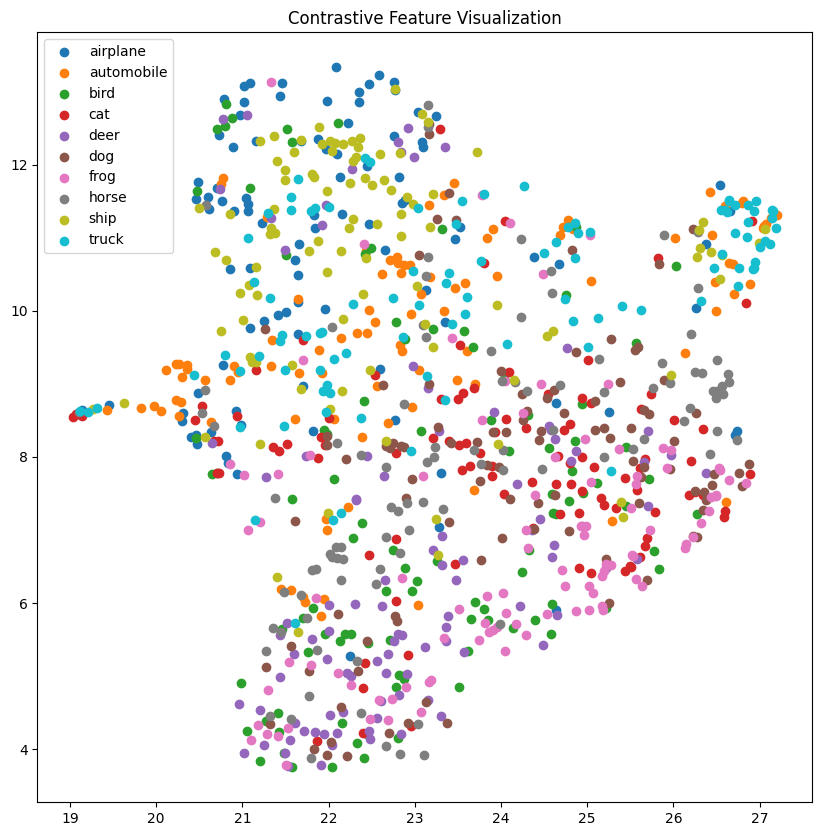

<Figure size 640x480 with 0 Axes>

In [78]:
# Visualize the features
class2name_list = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Reduce the dimensionality of the features
reducer = umap.UMAP()
scaled_test_features = StandardScaler().fit_transform(test_features)

reduced_features = reducer.fit_transform(scaled_test_features)

# Plot the features
plt.figure(figsize=(10, 10))
for i in range(10):
    test_label_array = np.array(test_data['label'])
    mask = test_label_array == i
    subsample = np.random.choice(np.where(mask)[0], size=100, replace=False)
    plt.scatter(reduced_features[subsample, 0], reduced_features[subsample, 1], label=class2name_list[i])
plt.title('Contrastive Feature Visualization')
plt.legend()
plt.show()
plt_save_path = os.path.join(base_dir, f'features_epoch{NUM_EPOCHS}.png')
plt.savefig(plt_save_path)

Error in callback <bound method AutoreloadMagics.pre_run_cell of <IPython.extensions.autoreload.AutoreloadMagics object at 0x13e94cad0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 15a243450, raw_cell="# Visualize the pixel space
# Reduce the dimension.." transformed_cell="# Visualize the pixel space
# Reduce the dimension.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/Assignment_3.ipynb#Y111sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: AutoreloadMagics.pre_run_cell() takes 1 positional argument but 2 were given

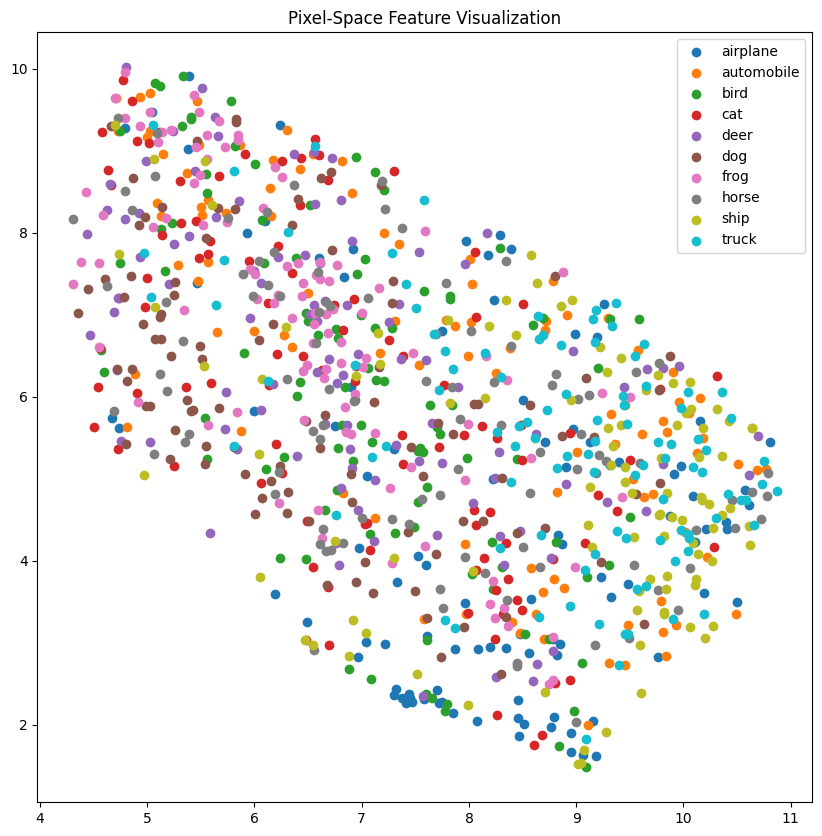

<Figure size 640x480 with 0 Axes>

In [79]:
# Visualize the pixel space
# Reduce the dimensionality of the pixel space
reducer = umap.UMAP()
test_img_array = np.concatenate(test_img_features, axis=0)
reduced_pixels = reducer.fit_transform(test_img_array.reshape(-1, 32 * 32 * 3))

# Plot the pixel space
plt.figure(figsize=(10, 10))
for i in range(10):
    mask = test_label_array == i
    subsample = np.random.choice(np.where(mask)[0], size=100, replace=False)
    plt.scatter(reduced_pixels[subsample, 0], reduced_pixels[subsample, 1], label=class2name_list[i])
plt.title('Pixel-Space Feature Visualization')
plt.legend()
plt.show()
plt_save_path = os.path.join(base_dir, f'pixels_epoch{NUM_EPOCHS}.png')
plt.savefig(plt_save_path)

### Q2: How do the visualizations of the contrastive learning features compare to the visualization of the image pixels? How tightly clustered are the points for the different classes in each of the two visualizations? How might your observations relate to the utility of these two sets of features for image classification? Write 3-4 sentences. (5 pts)

**Answer: add your answer to responses.tex**

## Run the following to create your submission files.
`linear_model_preds.csv` tests the accuracy of your ViT implementation trained with the SimCLR loss. (10 pts)

In [ ]:
simclr_vit.eval()

features, train_img_features = extract_features(simclr_model, val_dataloader)
test_features, test_img_features = extract_features(simclr_model, test_dataloader)

subsample = np.random.choice(features.shape[0], size=5000, replace=False)

features_subsample = features[subsample]
train_data_label = np.array(train_data['label'])[subsample]

classifier = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=100, solver="saga", verbose=1
    ),
)

classifier.fit(features_subsample, train_data_label)

predictions = classifier.predict(test_features)
pred_df = pd.DataFrame(predictions, columns=["preds"])
pred_save_path = os.path.join(base_dir, "linear_model_preds.csv")
pred_df.to_csv(pred_save_path, index=False)

print(f"Predictions saved to {pred_save_path}")

Error in callback <bound method AutoreloadMagics.pre_run_cell of <IPython.extensions.autoreload.AutoreloadMagics object at 0x13e94cad0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 13da247d0, raw_cell="simclr_vit.eval()

features, train_img_features = .." transformed_cell="simclr_vit.eval()

features, train_img_features = .." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/Assignment_3.ipynb#Y115sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: AutoreloadMagics.pre_run_cell() takes 1 positional argument but 2 were given

Epoch 1, change: 1
Epoch 2, change: 0.29619184
Epoch 3, change: 0.15728457
Epoch 4, change: 0.12532367
Epoch 5, change: 0.095524997
Epoch 6, change: 0.085019588
Epoch 7, change: 0.068168119
Epoch 8, change: 0.063717075
Epoch 9, change: 0.05032425
Epoch 10, change: 0.047199264
Epoch 11, change: 0.042727228
Epoch 12, change: 0.041623048
Epoch 13, change: 0.034714121
Epoch 14, change: 0.031970263
Epoch 15, change: 0.029561108
Epoch 16, change: 0.02676164
Epoch 17, change: 0.025997745
Epoch 18, change: 0.024213688
Epoch 19, change: 0.022809817
Epoch 20, change: 0.021630479
Epoch 21, change: 0.019921878
Epoch 22, change: 0.019233566
Epoch 23, change: 0.018139027
Epoch 24, change: 0.016961534
Epoch 25, change: 0.01620958
Epoch 26, change: 0.015586246
Epoch 27, change: 0.014764906
Epoch 28, change: 0.014236365
Epoch 29, change: 0.013671436
Epoch 30, change: 0.013427611
Epoch 31, change: 0.012885341
Epoch 32, change: 0.012593775
Epoch 33, change: 0.012195119
Epoch 34, change: 0.01204449
Epoch 

/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/venvDL/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/venvDL/lib/python3.14/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
    ~~~~~~~~^^
  File "/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/venvDL/lib/python3.14/site-packages/ipykernel/kernelbase.py", line 584, in shell_channel_thread_main
    _, msg2 = self.session.feed_identities(msg, copy=False)
              ~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "/Users/logan/Documents/dev/cornellspring2026/DeepLearning/cs4782/a3_release/venvDL/lib/python3.14/site-packages/jupyter_client/session.py", line 998, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/logan/Documents/dev/cornellspring2026/DeepLe